In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
from sklearn.preprocessing import StandardScaler

In [4]:
from sklearn.decomposition import PCA

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
from sklearn.linear_model import LogisticRegression

In [7]:
from sklearn.metrics import confusion_matrix

In [8]:
import matplotlib.pyplot as plt

In [9]:
import seaborn as sns

In [10]:
data = {
'Height': [170, 165, 180, 175, 160, 172, 168, 177, 162, 158],
'Weight': [65, 59, 75, 68, 55, 70, 62, 74, 58, 54],
'Age': [30, 25, 35, 28, 22, 32, 27, 33, 24, 21],
'Gender': [1, 0, 1, 1, 0, 1, 0, 1, 0, 0] # 1 = Male, 0 = Female
}

In [11]:
df = pd.DataFrame(data)
print(df)

   Height  Weight  Age  Gender
0     170      65   30       1
1     165      59   25       0
2     180      75   35       1
3     175      68   28       1
4     160      55   22       0
5     172      70   32       1
6     168      62   27       0
7     177      74   33       1
8     162      58   24       0
9     158      54   21       0


In [12]:
X = df.drop('Gender', axis=1)

In [13]:
y = df['Gender']

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[ 0.18419807  0.13867505  0.50910379]
 [-0.52425605 -0.69337525 -0.59764358]
 [ 1.60110632  1.52542554  1.61585117]
 [ 0.8926522   0.5547002   0.06640484]
 [-1.23271018 -1.24807544 -1.26169201]
 [ 0.46757972  0.83205029  0.95180275]
 [-0.09918358 -0.2773501  -0.15494463]
 [ 1.17603385  1.38675049  1.17315222]
 [-0.94932853 -0.83205029 -0.81899306]
 [-1.51609183 -1.38675049 -1.48304149]]


In [18]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

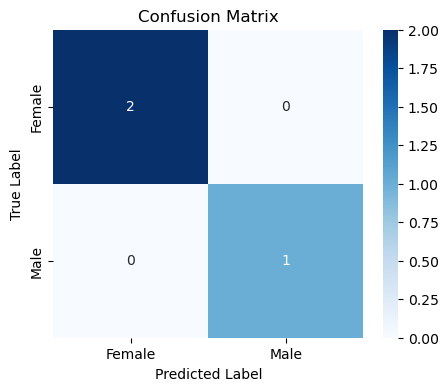

In [19]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Female', 'Male'],
yticklabels=['Female', 'Male'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [20]:
y_numeric = pd.factorize(y)[0]

In [21]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Axes: >

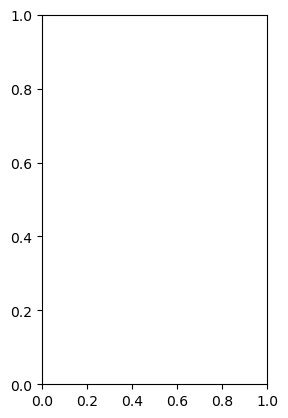

In [22]:
plt.subplot(1, 2, 1)

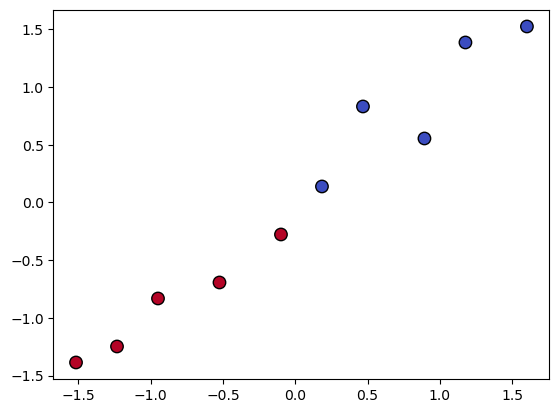

In [23]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k',
s=80)

Text(0.5, 0, 'Original Feature 1')

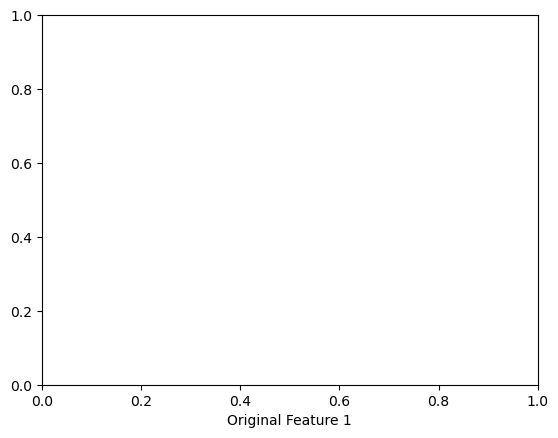

In [24]:
plt.xlabel('Original Feature 1')

Text(0, 0.5, 'Original Feature 2')

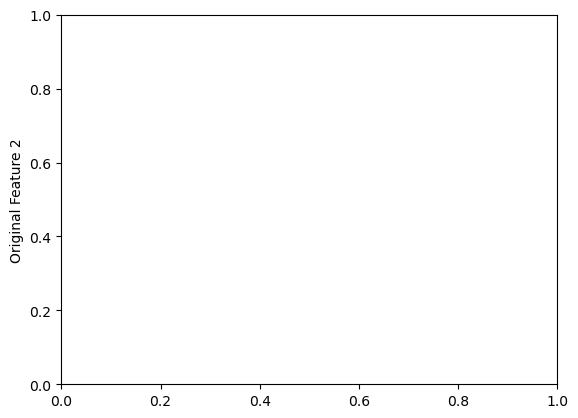

In [25]:
plt.ylabel('Original Feature 2')

Text(0.5, 1.0, 'Before PCA: Using First 2 Standardized Features')

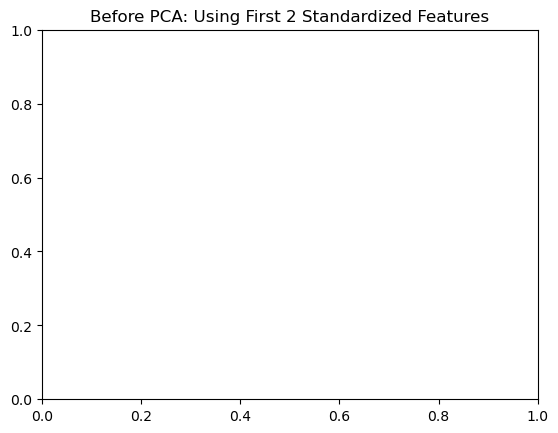

In [26]:
plt.title('Before PCA: Using First 2 Standardized Features')

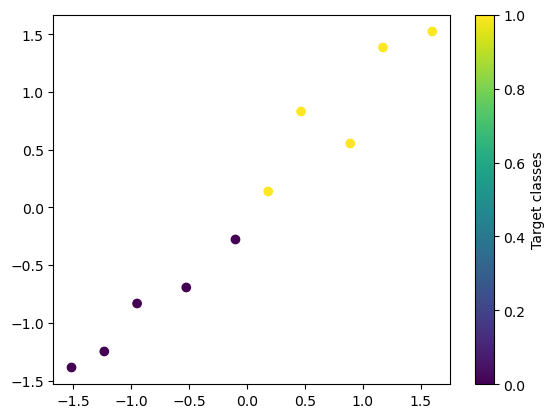

In [28]:
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y)
plt.colorbar(scatter, label='Target classes')
plt.show()

<Axes: >

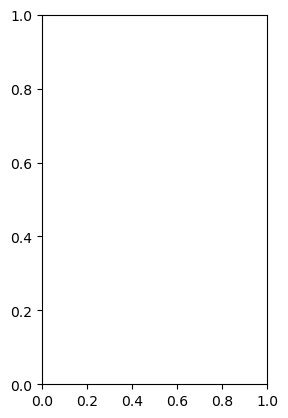

In [29]:
plt.subplot(1, 2, 2)

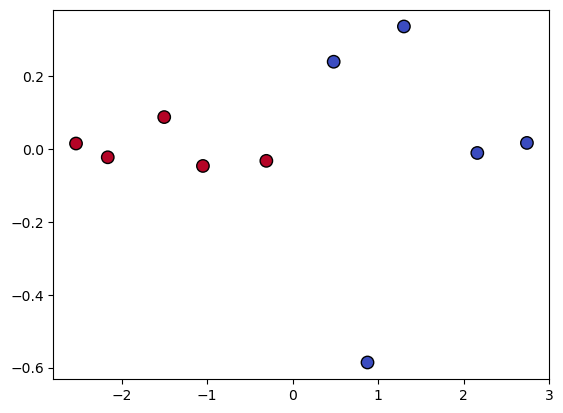

In [30]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)

Text(0.5, 0, 'Principal Component 1')

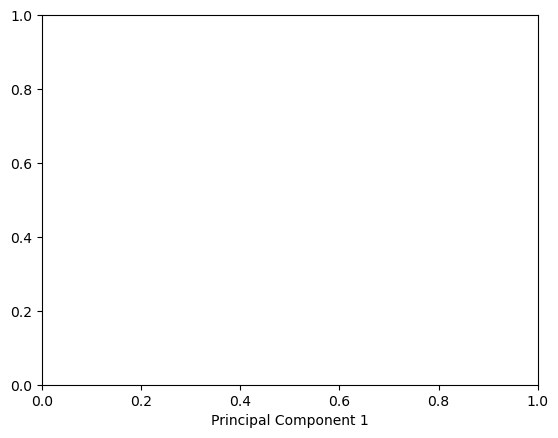

In [31]:
plt.xlabel('Principal Component 1')

Text(0, 0.5, 'Principal Component 2')

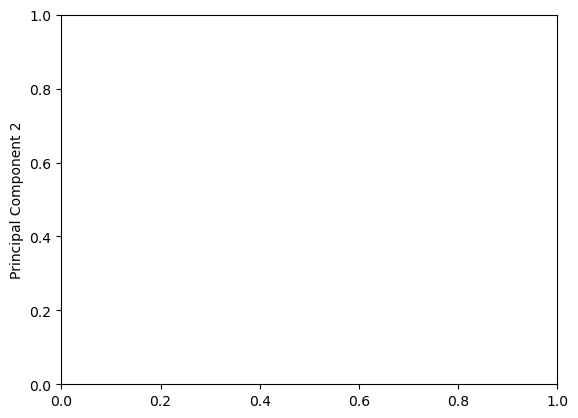

In [32]:
plt.ylabel('Principal Component 2')

Text(0.5, 1.0, 'After PCA: Projected onto 2 Principal Components')

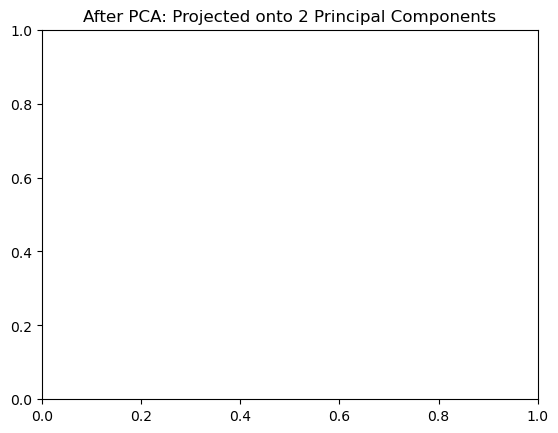

In [33]:
plt.title('After PCA: Projected onto 2 Principal Components')

In [34]:
plt.colorbar(label='Target classes')

RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

<Figure size 640x480 with 0 Axes>

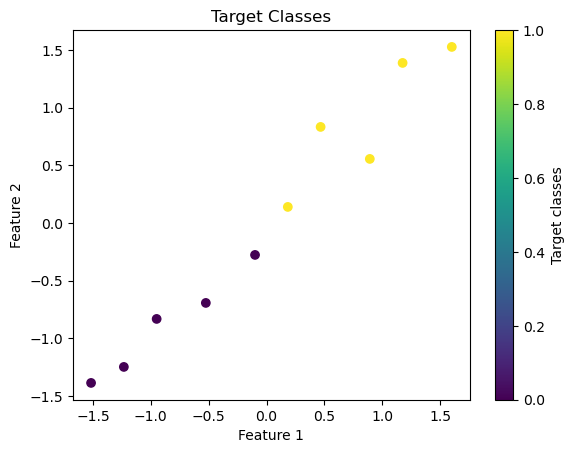

In [35]:
import matplotlib.pyplot as plt

scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Target Classes')

plt.colorbar(scatter, label='Target classes')

plt.show()